In [1]:
from elbow import KMeans
import numpy
import matplotlib.pyplot as pyplot

In [2]:
# toy data with some seperation for two classes
numpy.random.seed(0)
X = numpy.random.standard_normal((50,2))
X[:25,0] += 3
X[:25,1] -= 4
clusters = numpy.array([1] * 25 + [0] * 25)

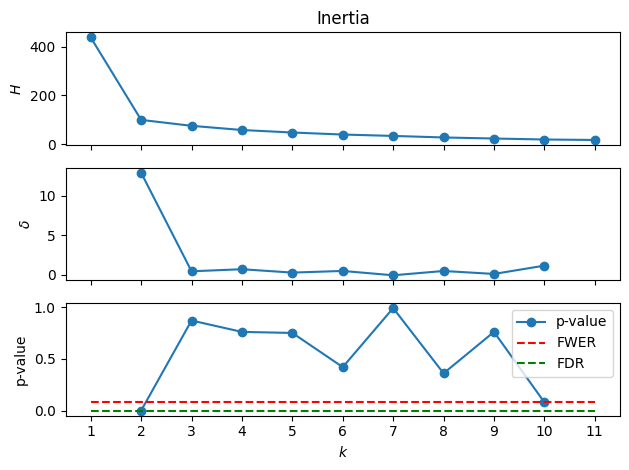

In [3]:
# Fit our clustering method with an additional elbow parameter called delta.
kmeans = KMeans()
kmeans.fit(X)

# We then create N uniform random samples from the ranges of our data (or their principal components if use_pca
# is set to True) to calculate p-values for our delta statistics.
kmeans.find_significant_k(X, N=100)

# And we can see the results.
kmeans.plot()

In [4]:
# The top graph shows cluster heterogeneity H (inertia for KMeans) for cluster sizes of k=1 to k=11

# The middle graph shows delta which is roughly the negative discrete second derivative of H. This will be large at 
# 'elbows' in H where there is high positive curvature in a discrete sense. Delta is also normalized by the
# first discrete derivative of H.

# The bottom graph shows estimated p-values for each k under the null hypothesis of the data being uniformly
# distributed. The dashed lines show p-value thresholds for rejecting when either controlling the Family-Wise Error
# Rate or the average False Discovery Rate.

In [5]:
# We can see the values of k that were determined to be significant by the FWER and FDR thresholds.
# For this simple example, both approaches select only a cluster size of 2.
kmeans.show_significant_k()

FWER: [2]
FDR: [2]


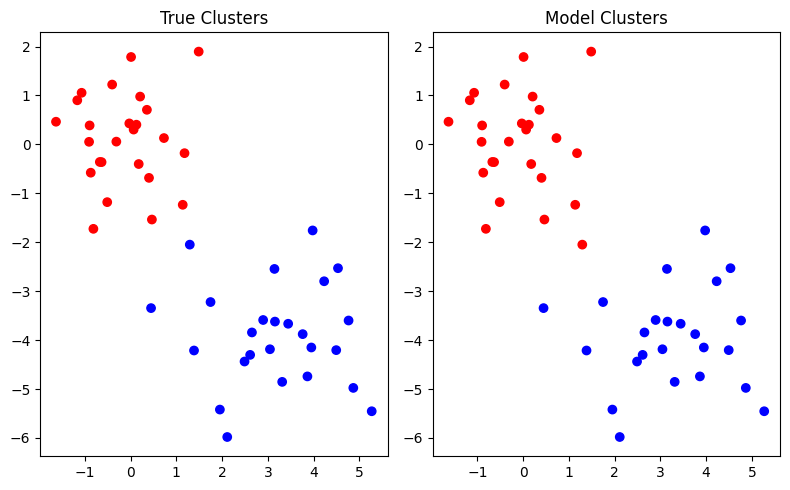

In [6]:
# And we can see visualize how the model splits up the data compared to the true labels.
colours = numpy.array(['red', 'blue'])
figure, axes = pyplot.subplots(1, 2, figsize=(8, 5))
axes[0].scatter(X[:, 0], X[:, 1], c=colours[clusters])
axes[0].set_title('True Clusters');
axes[1].scatter(X[:, 0], X[:, 1], c=colours[kmeans.get_labels(2)])
axes[1].set_title('Model Clusters')
figure.tight_layout();

In [ ]:
# They only differ on one data point near the boundary between the two groups.